# Train an example neural-network pilot with PPO

This notebook exercises the repository's **real `PPOTrainer` pipeline** end to end. The
`HybridSkillPilot` chooses one of the complete `SkillManager` skill catalogue and predicts
the skill's continuous parameters. To keep the example quick and reproducible, a small
simulator-neutral learning backend implements the same contract as a JSBSim/BVR Sim
backend. Only `backend_factory` needs to change for simulator-backed training.

The example writes checkpoints, JSONL diagnostics, MLflow metrics, and demonstration
trajectories below `artifacts/rl_pilot_notebook/`. It does not claim that the smoke backend
produces a combat-ready policy; it demonstrates and validates the training workflow.


## Setup

Install the optional machine-learning dependencies from the repository root, then restart
the kernel if necessary:

```bash
python -m pip install -e '.[ml]'
```

The environment variables in the next cell let you shorten or extend the run without
editing the notebook. Defaults are deliberately small enough for a CPU demonstration.


In [8]:
import json
import os
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Support kernels started either in the repository root or in notebooks/.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "bvr_behavior_prediction").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "bvr_sim_source") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "bvr_sim_source"))

from bvr_behavior_prediction.rl.config import PilotTrainingConfig
from bvr_behavior_prediction.rl.environment import BluePilotEnvironment
from bvr_behavior_prediction.rl.trainer import PPOTrainer

SEED = int(os.getenv("BVR_PILOT_SEED", "7"))
EPOCHS = int(os.getenv("BVR_PILOT_EPOCHS", "150"))
EPISODE_SECONDS = float(os.getenv("BVR_PILOT_EPISODE_SECONDS", "120"))
OUTPUT_DIR = Path(os.getenv(
    "BVR_PILOT_OUTPUT", REPO_ROOT / "artifacts/rl_pilot_notebook"
)).resolve()
DEVICE = os.getenv("BVR_PILOT_DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print({"device": DEVICE, "epochs": EPOCHS, "output": str(OUTPUT_DIR)})


{'device': 'cuda', 'epochs': 150, 'output': 'C:\\Users\\theon\\Trajectory_Classification\\artifacts\\rl_pilot_notebook'}


## A fast backend with the production environment contract

`BluePilotEnvironment` expects a backend with `reset(seed)`,
`step(blue_action, red_action)`, and `close()`. This deterministic backend models only
range, lock, launch, survival, and altitude signals. The observation contains eight
normalized, fully numeric values. It is a learning smoke test—not a flight model.

For JSBSim/BVR Sim, replace `smoke_backend_factory` with a factory that returns your
simulator backend; keep `make_environment`, the trainer, and the analysis cells unchanged.


In [9]:
OBSERVATION_SIZE = 150


class LearningSmokeBackend:
    """Minimal deterministic engagement used to exercise PPO quickly."""

    def __init__(self, scenario, recording_path=None):
        self.scenario = scenario
        self.recording_path = Path(recording_path) if recording_path else None
        self.rng = None
        self.step_index = 0
        self.range_m = float(scenario["range_m"])
        self.altitude_m = float(scenario["blue_altitude_m"])
        self.locked = False
        self.fired = False
        self.destroyed = False
        self.last_skill = 0.0

    def _observation(self):
        return np.asarray([
            np.clip(self.range_m / 50_000.0, 0.0, 1.0),
            self.scenario["bearing_deg"] / 180.0,
            self.altitude_m / 12_000.0,
            self.scenario["red_altitude_m"] / 12_000.0,
            float(self.locked),
            float(self.fired),
            np.clip(self.step_index / max(EPISODE_SECONDS, 1.0), 0.0, 1.0),
            self.last_skill,
        ], dtype=np.float32)

    def reset(self, seed):
        self.rng = np.random.default_rng(seed)
        self.step_index = 0
        self.range_m = float(self.scenario["range_m"])
        self.locked = self.fired = self.destroyed = False
        self.last_skill = 0.0
        return self._observation()

    def step(self, blue_action, red_action):
        # The red action is deliberately fixed by BluePilotEnvironment.
        assert red_action["skill_name"] == "maintain_heading"
        skill = blue_action["skill_name"]
        self.step_index += 1
        self.range_m = max(1_000.0, self.range_m - 550.0)
        self.locked = self.locked or skill == "lock_target"
        just_fired = skill in {"launch", "secondary_shot"}
        self.fired = self.fired or just_fired
        self.destroyed = self.destroyed or (
            just_fired and self.locked and self.range_m < 35_000.0
        )
        self.last_skill = sum(skill.encode("utf8")) % 33 / 32.0
        terminated = self.destroyed
        info = {
            "blue_altitude_m": self.altitude_m,
            "blue_alive": True,
            "target_locked": self.locked,
            "fired": just_fired,
            "fired_with_lock": just_fired and self.locked,
            "opponent_destroyed": self.destroyed,
        }
        return self._observation(), 0.0, terminated, info

    def close(self):
        if self.recording_path:
            self.recording_path.parent.mkdir(parents=True, exist_ok=True)
            self.recording_path.write_text(
                "FileType=text/acmi/tacview\nFileVersion=2.2\n# smoke-backend demonstration\n",
                encoding="utf8",
            )


def smoke_backend_factory(scenario_dict, recording_path=None):
    return LearningSmokeBackend(scenario_dict, recording_path)


## Configure the pipeline

Every epoch samples at least three randomized engagement geometries. The example uses a
one-second planning horizon, short episodes, a compact network, and small PPO minibatches.
Increase `BVR_PILOT_EPOCHS` and `BVR_PILOT_EPISODE_SECONDS` for a longer experiment.


In [10]:
config = PilotTrainingConfig(
    seed=SEED,
    epochs=EPOCHS,
    episode_duration_s=EPISODE_SECONDS,
    planning_horizon_s=1.0,
    scenarios_per_epoch=3,
    hidden_size=64,
    learning_rate=3e-4,
    update_epochs=120,
    minibatch_size=64,
    checkpoint_interval=max(1, EPOCHS // 5),
    diagnostic_interval=1,
    output_dir=OUTPUT_DIR,
    mlflow_experiment="pilot-notebook-smoke-example",
    mlflow_tracking_uri=f"sqlite:///{(REPO_ROOT / 'artifacts/mlflow.db').as_posix()}",
)

# Avoid mixing metrics from an earlier execution of this notebook.
for generated_file in (OUTPUT_DIR / "training_metrics.jsonl", OUTPUT_DIR / "best_model.pt"):
    generated_file.unlink(missing_ok=True)


def make_environment(scenario, recording_path=None):
    return BluePilotEnvironment(
        smoke_backend_factory,
        scenario,
        planning_horizon_s=config.planning_horizon_s,
        episode_duration_s=config.episode_duration_s,
        recording_path=recording_path,
    )

print(json.dumps(config.as_dict(), default=str, indent=2))


{
  "planning_horizon_s": 1.0,
  "episode_duration_s": 120.0,
  "scenarios_per_epoch": 3,
  "epochs": 150,
  "simulation_dt_s": 0.2,
  "seed": 7,
  "hidden_size": 64,
  "learning_rate": 0.0003,
  "discount": 0.99,
  "gae_lambda": 0.95,
  "clip_ratio": 0.2,
  "update_epochs": 120,
  "minibatch_size": 64,
  "entropy_coefficient": 0.01,
  "value_coefficient": 0.5,
  "gradient_clip": 0.5,
  "checkpoint_interval": 30,
  "diagnostic_interval": 1,
  "output_dir": "C:\\Users\\theon\\Trajectory_Classification\\artifacts\\rl_pilot_notebook",
  "mlflow_experiment": "pilot-notebook-smoke-example",
  "mlflow_tracking_uri": "sqlite:///C:/Users/theon/Trajectory_Classification/artifacts/mlflow.db",
  "reward": {
    "crashed": -100.0,
    "shot_down": -150.0,
    "ground_clearance": 0.02,
    "target_lock_acquired": 2.0,
    "fired_with_lock": 8.0,
    "incoming_missile_avoided": 20.0,
    "opponent_destroyed": 250.0,
    "fired_without_lock": -4.0
  }
}


## Train an example pilot

This is the training cell. `PPOTrainer.train()` collects scenario batches, computes GAE
advantages, performs clipped PPO updates, tracks the run in MLflow, saves the best model,
and periodically records a fixed-seed demonstration.


In [11]:
trainer = PPOTrainer(
    env_factory=make_environment,
    observation_size=OBSERVATION_SIZE,
    config=config,
    device=DEVICE,
)
trained_pilot = trainer.train()
print(f"Trained {type(trained_pilot).__name__} with {sum(p.numel() for p in trained_pilot.parameters()):,} parameters")
print(f"Best checkpoint: {OUTPUT_DIR / 'best_model.pt'}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x8 and 150x64)

## Visualize training performance

The following cells intentionally come **after training**. They read the persisted JSONL
rather than private trainer state, so the same analysis also works after reopening the
notebook. Return should trend upward as the pilot discovers lock/launch sequences; PPO
loss need not be monotonic.


In [5]:
metrics = pd.read_json(OUTPUT_DIR / "training_metrics.jsonl", lines=True)
metrics


,epoch,mean_return,loss,episodes,best_return
0,1,169.793333,7030.520371,3,169.793333
1,2,168.486667,7293.797241,3,169.793333
2,3,85.220000,3316.201965,3,169.793333
3,4,253.640000,14438.568359,3,253.640000
4,5,259.093333,12524.557129,3,259.093333
5,6,173.113333,7704.469116,3,259.093333
6,7,79.933333,2793.982788,3,259.093333
7,8,81.866667,3081.075867,3,259.093333


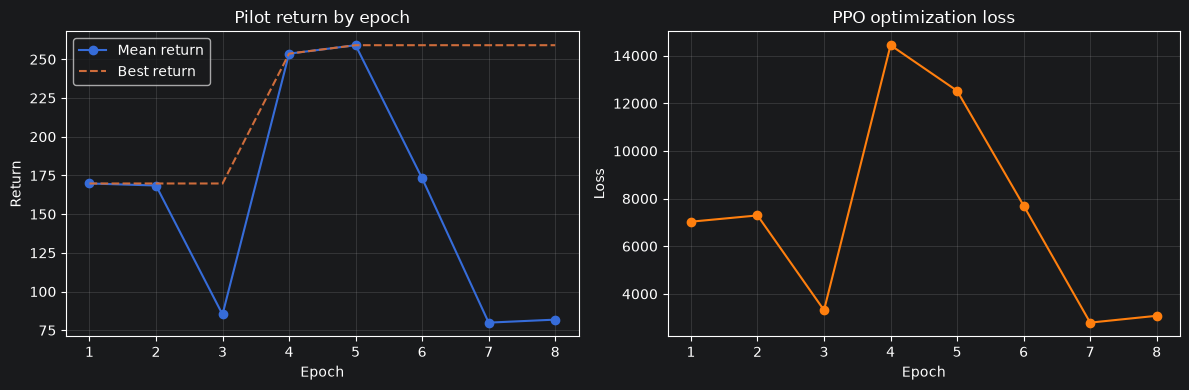

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics["epoch"], metrics["mean_return"], marker="o", label="Mean return")
axes[0].plot(metrics["epoch"], metrics["best_return"], linestyle="--", label="Best return")
axes[0].set(title="Pilot return by epoch", xlabel="Epoch", ylabel="Return")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(metrics["epoch"], metrics["loss"], color="tab:orange", marker="o")
axes[1].set(title="PPO optimization loss", xlabel="Epoch", ylabel="Loss")
axes[1].grid(alpha=0.25)
figure.tight_layout()
plt.show()


## Inspect the trained pilot

A sample rollout gives a compact qualitative check of the policy selected from the
best checkpoint. In a simulator-backed experiment, inspect the corresponding ACMI files
under `demonstrations/` alongside these numerical diagnostics.


Evaluation return: 256.52


,decisions
skill,
crank_target_left,2
search,2
notch_left,2
beam_target_left,2
lag_pursuit,2
support_missile,2
preemptive_crank,1
maintain_heading,1
climb_to_altitude,1


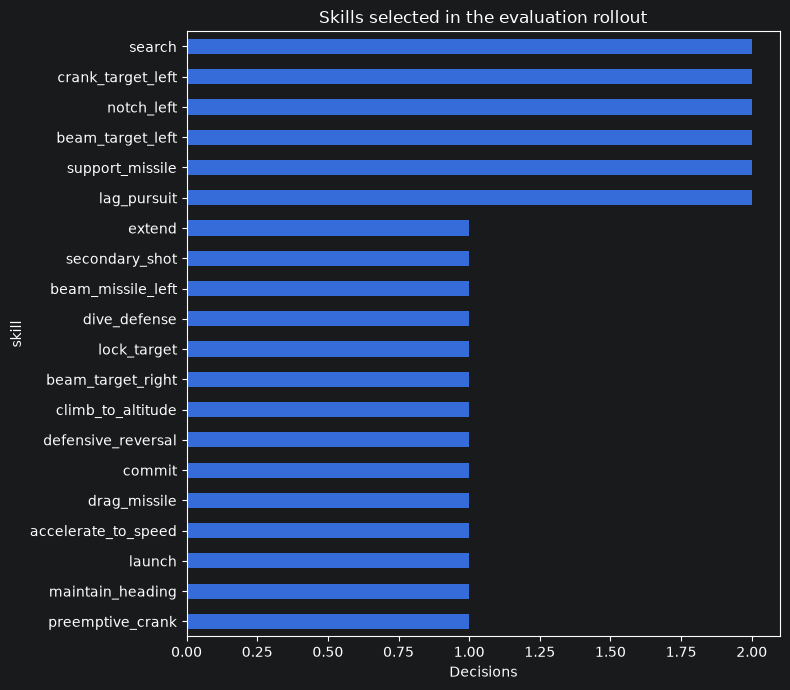

In [7]:
scenario = trainer.sampler.sample_batch(3)[0]
rollout, evaluation_return, final_info = trainer._episode(scenario, SEED)
selected_skills = [trained_pilot.skill_names[index] for index in rollout.skills]
skill_counts = pd.Series(selected_skills).value_counts().rename_axis("skill").rename("decisions")
print(f"Evaluation return: {evaluation_return:.2f}")
display(skill_counts.to_frame())

skill_counts.sort_values().plot.barh(figsize=(8, max(3, len(skill_counts) * 0.35)))
plt.title("Skills selected in the evaluation rollout")
plt.xlabel("Decisions")
plt.tight_layout()
plt.show()


## Next steps

- Replace only `smoke_backend_factory` with a JSBSim/BVR Sim backend implementing the
  documented contract.
- Increase epochs and episode duration through the environment variables.
- Compare MLflow runs and inspect seeded ACMI demonstrations before deploying a policy.
- Treat rising return in this smoke backend as a pipeline check, not evidence of flight or
  tactical competence.
